In [1]:
from meta import ROOT_DIR
from bez.segments import segments
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import scipy
import networkx as nx

# Skeleton extraction
## Trapped-ball segmentation
### Decorative Line Detection
#### Detection de points centraux des lignes : 
+ Convolution avec un "second derivative of a Gaussian"
+ detections des maximas locaux : nonmax-ima suppression as in the original Canny edge detector
+ Récupère en même temps la direction de la ligne

####

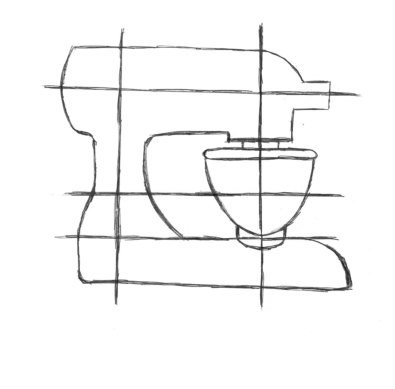

Max line width: 10


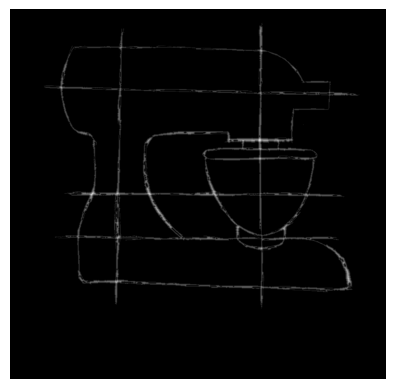

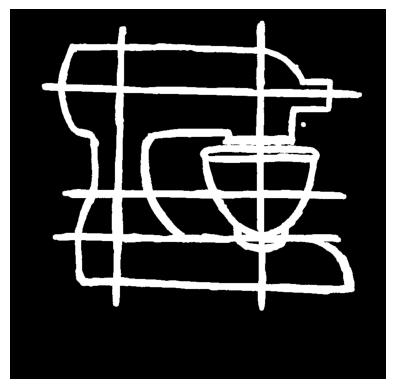

[False  True]


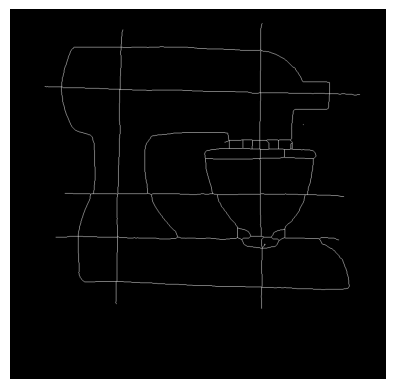

In [2]:
# Skeleton extraction
from skimage.morphology import skeletonize, dilation, erosion, remove_small_holes
from skimage.morphology import disk
from skimage.filters import threshold_otsu

test_image = io.imread(ROOT_DIR /"data/original_paper/figure_2/input.png")
test_image = test_image[:, :, 0]  

plt.imshow(test_image, cmap="gray")
plt.axis("off")
plt.show()

t = threshold_otsu(test_image)
test_image_binary = test_image < t

thicknesses = np.zeros_like(test_image_binary, dtype=int)

c = 1
max_line_width_detection = test_image_binary.copy()
while np.sum(max_line_width_detection) > 0:
    # iterate the erosion
    tmp = erosion(max_line_width_detection, disk(1))
    # find the difference
    diff = max_line_width_detection ^ tmp > 0
    thicknesses[diff] = c
    max_line_width_detection = tmp
    c += 1

print(f"Max line width: {c}")

plt.imshow(thicknesses, cmap="gray")
plt.axis("off")
plt.show()

test_image_binary = dilation(test_image_binary, disk(c//2))

plt.imshow(test_image_binary, cmap="gray")
plt.axis("off")
plt.show()

skeleton = skeletonize(test_image_binary, method="zhang")
print(np.unique(skeleton))
plt.imshow(skeleton, cmap="gray")
plt.axis("off")
plt.show()

(array([660614,      0,      0,     13,      0,   6582,    151,      0,
           76,      4]), array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]))


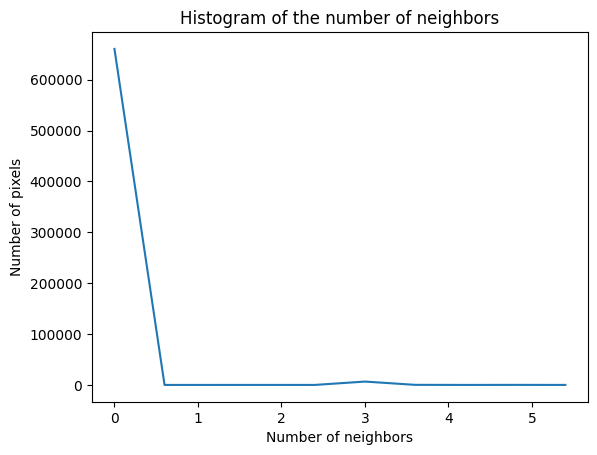

/tmp/ipykernel_108772/1099772582.py:23: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(sub_image, cmap="gray")
/tmp/ipykernel_108772/1099772582.py:23: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(sub_image, cmap="gray")


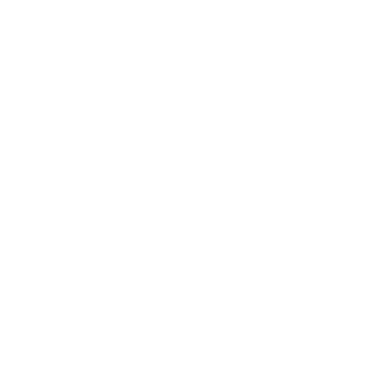

In [3]:
import scipy.signal



kernel = np.ones((3, 3), dtype=int)

n = scipy.signal.convolve2d(
    skeleton.astype(int), kernel, mode="same"
)
n*= skeleton
h = np.histogram(n)
print(h)
plt.plot(h[1][:-1], h[0])
plt.xlabel("Number of neighbors")
plt.ylabel("Number of pixels")
plt.title("Histogram of the number of neighbors")
plt.show()

c = np.where(n == 8)

c = (1335, 1112)
sub_image = skeleton[c[0]-100:c[0]+100, c[1]-100:c[1]+100]
plt.imshow(sub_image, cmap="gray")
plt.axis("off")
plt.show()



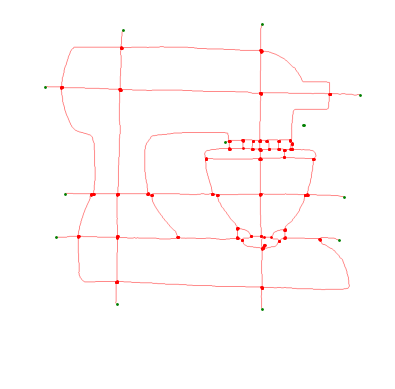

In [4]:
from matplotlib.colors import ListedColormap

plt.scatter(np.where(n == 2)[1], np.where(n == 2)[0], color="green", s=1)
plt.scatter(np.where(n >= 4)[1], np.where(n >= 4)[0], color="red", s=1)
plt.imshow(n, cmap=ListedColormap(["white", "white", "green", "black", "red", "white", "white", "white"]))
plt.axis("off")
plt.show()

# Topoligical graph extraction

/tmp/ipykernel_108772/3704153362.py:9: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(sub_image, cmap="gray")
/tmp/ipykernel_108772/3704153362.py:9: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(sub_image, cmap="gray")


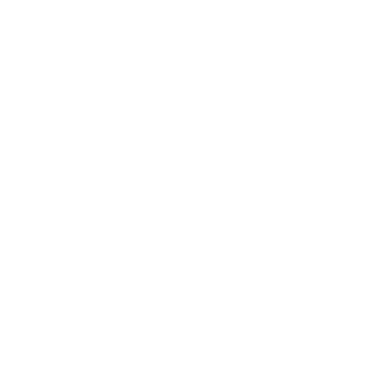

In [5]:
visu_i, visu_j = (1335, 1112)
visu_radius = 50


sub_image = skeleton[
    visu_i-visu_radius:visu_i+visu_radius,
    visu_j-visu_radius:visu_j+visu_radius
]
plt.imshow(sub_image, cmap="gray")
plt.axis("off")
plt.show()

def visualize_subgraph(G, visu_i=1335, visu_j=1112, visu_radius=50, full_graph=False): 
    plt.figure(figsize=(8, 8))
    if full_graph:
        subgraph = G
    else:
        sub_nodes = [
            (i, j)
            for i in range(visu_i - visu_radius, visu_i + visu_radius)
            for j in range(visu_j - visu_radius, visu_j + visu_radius)
            if (i, j) in G
        ]
        subgraph = G.subgraph(sub_nodes)
    pos = {node: (node[1], node[0]) for node in subgraph.nodes}

    if isinstance(subgraph, nx.MultiGraph):
        # Draw nodes
        nx.draw_networkx_nodes(subgraph, pos=pos, node_size=10, node_color='blue')
        # Draw edges with curvature for multiplicity
        for u, v, keys in subgraph.edges(keys=True):
            num_edges = subgraph.number_of_edges(u, v)
            if num_edges == 1:
                nx.draw_networkx_edges(subgraph, pos, edgelist=[(u, v)], edge_color='gray')
            else:
                # Draw each edge with a different curvature
                for k, key in enumerate(subgraph[u][v]):
                    rad = 0.1 * (k - (num_edges - 1) / 2)
                    nx.draw_networkx_edges(
                        subgraph, pos, edgelist=[(u, v)], edge_color='gray', connectionstyle=f'arc3,rad={rad}'
                    )
    else:
        nx.draw(subgraph, pos=pos, node_size=1, edge_color='gray', node_color='blue', with_labels=False)
    plt.gca().invert_yaxis()
    plt.show()



/tmp/ipykernel_108772/987484298.py:11: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = plt.imshow(sub_thicknesses_max, cmap="viridis")
/tmp/ipykernel_108772/987484298.py:11: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = plt.imshow(sub_thicknesses_max, cmap="viridis")


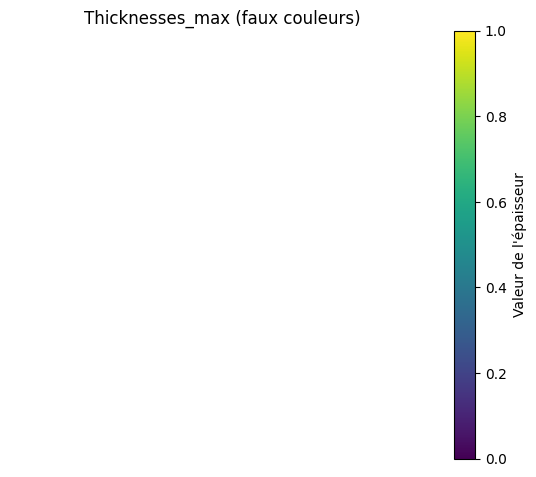

In [6]:
from scipy.ndimage import maximum_filter

thicknesses_max = maximum_filter(thicknesses, size=3)

sub_thicknesses_max = thicknesses_max[
    visu_i-visu_radius:visu_i+visu_radius,
    visu_j-visu_radius:visu_j+visu_radius
]

plt.figure(figsize=(6, 6))
im = plt.imshow(sub_thicknesses_max, cmap="viridis")
plt.axis("off")
plt.title("Thicknesses_max (faux couleurs)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Valeur de l'épaisseur")
plt.show()



bool (810, 824)
int64


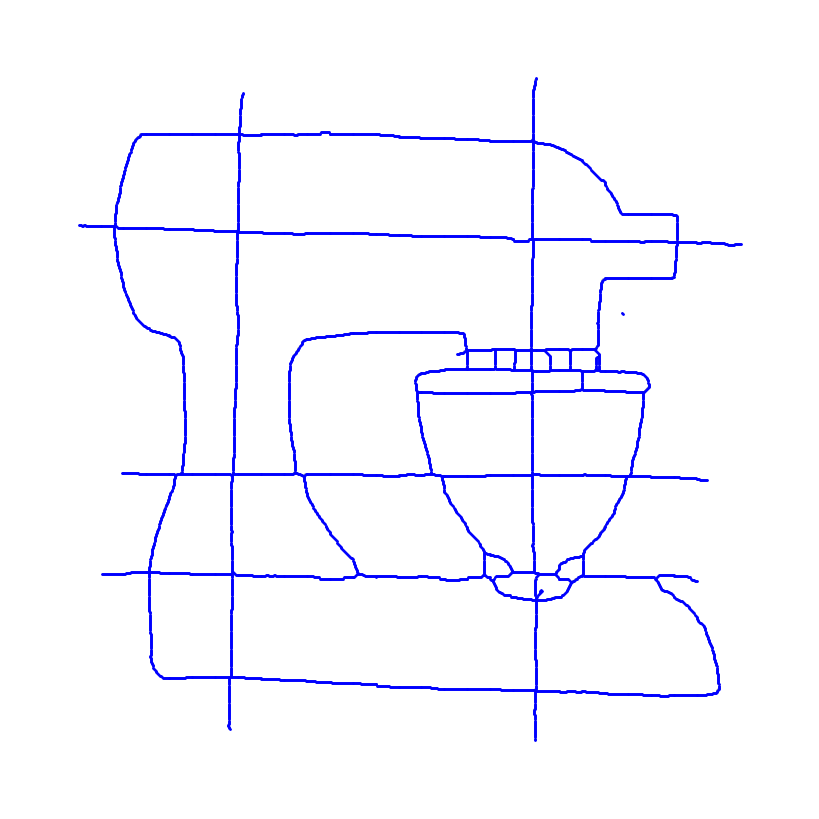

In [7]:
thicknesses = thicknesses_max
skeleton = skeleton


# skeleton = np.array(
#     [
#         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#         [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
#         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#     ]
# )

print(skeleton.dtype, skeleton.shape)
print(thicknesses.dtype)
# Creation of the cluster graph
cluster_G = nx.Graph()

for i in range(skeleton.shape[0]):
    for j in range(skeleton.shape[1]):
        if skeleton[i, j]:
            cluster_G.add_node((i, j), thickness=thicknesses[i, j])

for node in cluster_G.nodes:
    i, j = node
    # t = cluster_G.nodes[node]["thickness"]
    # for ni in range(max(0, i - t), min(skeleton.shape[0], i + t + 1)):
    #     for nj in range(max(0, j - t), min(skeleton.shape[1], j + t + 1)):
    for ni in range(max(0, i - 1), min(skeleton.shape[0], i + 2)):
        for nj in range(max(0, j - 1), min(skeleton.shape[1], j + 2)):
            if (ni, nj) != (i, j) and skeleton[ni, nj]:
                cluster_G.add_edge((i, j), (ni, nj), weight=(i - ni) ** 2 + (j - nj) ** 2)

visualize_subgraph(cluster_G,full_graph=True)

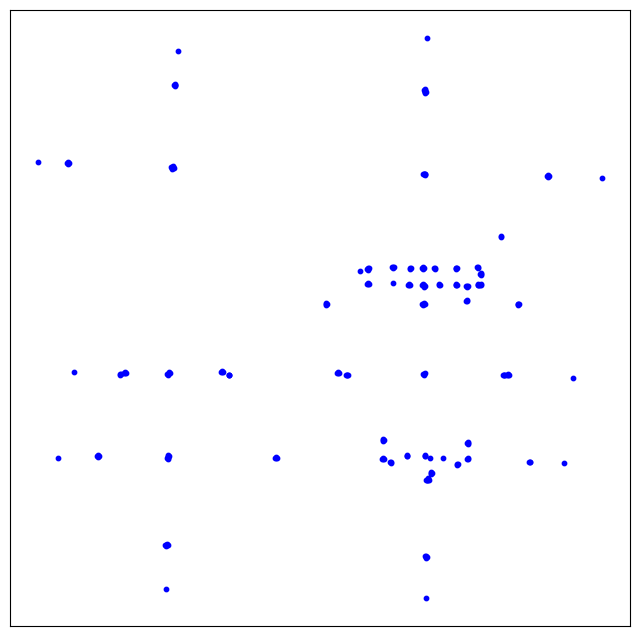

Nombre maximal d'arêtes entre deux sommets : 2


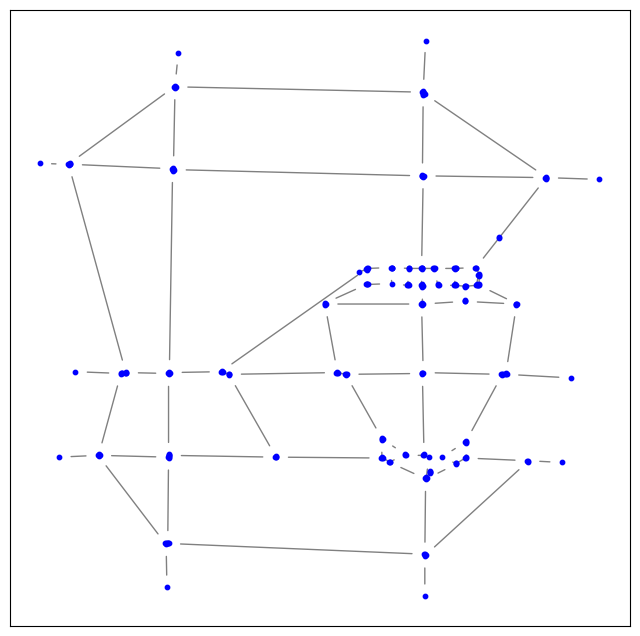

In [8]:
from tqdm import tqdm
# Extract topological graph from the MST
topological_graph = nx.MultiGraph()
leafs = [node for node, degree in cluster_G.degree() if degree == 1]
junctions = [node for node, degree in cluster_G.degree() if degree > 2]
# on ne garde pas les noeuds de degré 0 qui sont des pixels isolés
for leaf in leafs:
    topological_graph.add_node(leaf)
for junction in junctions:
    topological_graph.add_node(junction)

visualize_subgraph(topological_graph, full_graph=True)

for node in cluster_G.nodes:
    cluster_G.nodes[node]["closed"] = False

def is_junction(node):
    return cluster_G.degree(node) > 2
def is_leaf(node):
    return cluster_G.degree(node) == 1


for st in cluster_G.nodes:
    if cluster_G.nodes[st]["closed"]:
        continue
    # otherwise, we explore the graph from this node
    # Until we either connect 2 leafs or junctions or loop
    neighbors = list(cluster_G.neighbors(st))
    pixel_line = [st]
    found_first_endpoint = is_leaf(st) or is_junction(st)
    for neigh in neighbors:
        if cluster_G.nodes[neigh]["closed"]:
            continue
        current_node = neigh
        while True:
            pixel_line.append(current_node)

            if is_leaf(current_node) or is_junction(current_node) : 
                # On ne pourrait les fermer que si ce sont des leaf, mais pas gravissime de pas le faire
                # Par contre faut surtout pas fermer une jonction parce que il pourrait rester des trucs à explorer depuis là
                if not found_first_endpoint:
                    found_first_endpoint = True
                    pixel_line.reverse() # Comment ça l'endpoint est bien au début de la liste
                    current_node = st # On repart de l'autre coté
                else :
                    topological_graph.add_edge(pixel_line[0], pixel_line[-1], pixels=np.array(pixel_line))
                    pixel_line = [st] # pas vide car si c'est une jonction on va à la prochaine itération du for repartir sur une autre branche
                    break

            elif current_node == st:
                # We are back to the starting point, we close the circle
                assert not found_first_endpoint # Si on est dans un cercle impossible d'avoir trouvé un endpoint
                cluster_G.nodes[current_node]["closed"] = True
                topological_graph.add_edge(pixel_line[0], pixel_line[-1], pixels=np.array(pixel_line))
                pixel_line = [st] # cf au dessus même si ici ce sera normalement jamais une jonction
                break
            
            # Dans ce cas là on continue juste de suivre le chemin    
            # assert cluster_G.degree(current_node) == 2, f"Le noeud courant doit avoir exactement 2 voisins, il en a {cluster_G.degree(current_node)}"
            
            nexts = list(cluster_G.neighbors(current_node))
            next_node = nexts[1] if nexts[0] == pixel_line[-2] else nexts[0]
            cluster_G.nodes[current_node]["closed"] = True
            current_node = next_node
        # Ici, on a soit trouvé une courbe en entier, soit qu'un endpoint, et on va continuer de l'autre coté.
    cluster_G.nodes[st]["closed"] = True

# for st in leafs + junctions:
#     if cluster_G.nodes[st]["closed"]:
#         # Devrait pas arriver
#         continue
#     # otherwise, we explore the graph from this node (bfs)
#     #print(f"Exploring from start node: {st}")
#     neighbors = list(cluster_G.neighbors(st))
#     for neigh in neighbors:
#         #print("starting line with ", st, neigh)
#         # On explore les différentes directions
#         if cluster_G.nodes[neigh]["closed"] :
#             continue
#         current_node = neigh
#         pixels_list = [st, current_node]
#         while not (is_leaf(current_node) or is_junction(current_node)) :
#             #print("current line :",pixels_list)
#             assert cluster_G.degree(current_node) == 2
#             nexts = list(cluster_G.neighbors(current_node))
#             next_node = nexts[1] if nexts[0] == pixels_list[-2] else nexts[0]
#             pixels_list.append(next_node)
#             cluster_G.nodes[current_node]["closed"] = True
#             current_node = next_node
#         topological_graph.add_edge(st, current_node, pixels=np.array(pixels_list))
#     #print("Closing node ", st)
#     cluster_G.nodes[st]["closed"] = True

max_edges = 0
for u, v in topological_graph.edges():
    num_edges = topological_graph.number_of_edges(u, v)
    if num_edges > max_edges:
        max_edges = num_edges
print("Nombre maximal d'arêtes entre deux sommets :", max_edges)

visualize_subgraph(topological_graph, full_graph=True)

In [9]:
# # Pruning the MST

# def prune_mst(mst, thicknesses):
#     # prune in place 
#     # Leaves are nodes with degree 1 in the MST
#     leaves = [node for node in mst.nodes if mst.degree(node) == 1] # voir ce qu'on fait avec les noeuds de degre 0
#     for leaf in leaves:
#         mst.nodes[leaf]["removed_branch_length"] = 0
#     while leaves:
#         leaf = leaves.pop()
#         neighbor = mst.neighbors(leaf) # there should be only one neighbor for a leaf
#         if not neighbor:
#             continue
#         if mst.nodes[leaf]["removed_branch_length"] + 1 < thicknesses[leaf]:
#             if mst.degree(neighbor) == 2:
#                 leaves.append(neighbor)
#                 mst.nodes[neighbor]["removed_branch_length"] = mst.nodes[leaf]["removed_branch_length"] + 1
#             mst.remove_node(leaf)

# prune_mst(mst, thicknesses)

# visualize_subgraph(mst)


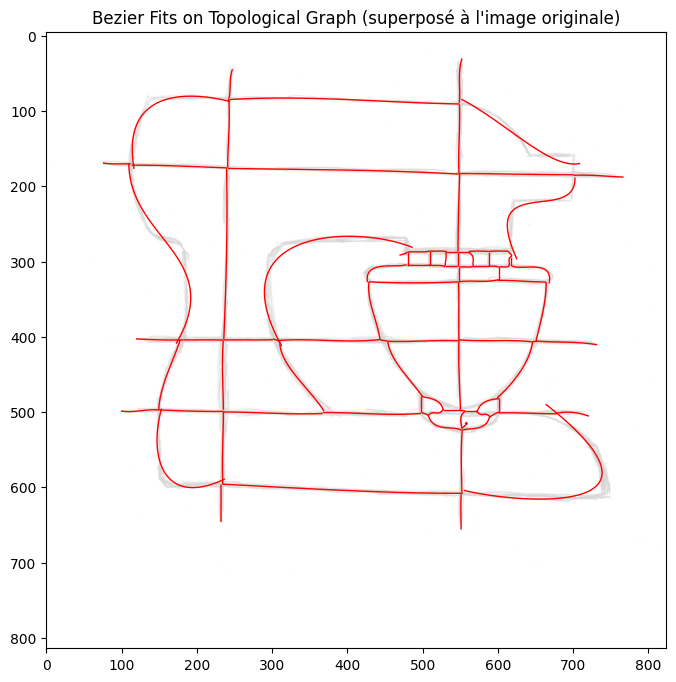

In [10]:
from bez.bezier import fit_bezier, interpolate_bezier

bezier_fits = []

for i,edge in enumerate(topological_graph.edges(data=True, keys=True)):
    u, v,key, data = edge
    pixels = data["pixels"]
    if len(pixels) < 3:
        continue
    # Fit a Bezier curve to the pixel line
    p = np.vstack((pixels[:, 0], pixels[:, 1]))
    instants = np.linspace(0, 1, p.shape[1])
    control_points = fit_bezier(p,instants)
    bezier_fits.append(((u,v, key),control_points))
    
# Visualize the Bezier fits
def visualize_bezier_fits(bezier_fits, topological_graph):
    plt.figure(figsize=(8, 8))
    # Superpose l'image originale
    plt.imshow(test_image, cmap="gray", alpha=0.2)
    for _, control_points in bezier_fits:
        t = np.linspace(0, 1, 100)
        bezier_curve = interpolate_bezier(control_points, t)
        plt.plot(bezier_curve[1], bezier_curve[0], color='red', linewidth=1)
    plt.axis("equal")
    plt.title("Bezier Fits on Topological Graph (superposé à l'image originale)")
    plt.show()
visualize_bezier_fits(bezier_fits, topological_graph)


In [ ]:
"""
Pour la perturbation : choisir une des 3 opération possible
+ Changement de degré : choix d'une arrête aléatoire
+ Merge / split
+ Overlap / Dissociation


Merge : choisir un noeud aléatoire pondérés par degré - 1 
Split : Choix d'une hyperedge de long >= 3 puis d'un noeud non extrémité dedans, et split là dessus

Overlap : Trouve noeud tq : extrémité d'un hyperedge appartenant à un autre, uniforme sur les autres auquel il appartient,
puis uniforme sur 1 ou 2 voisins ce qui identifie une edge



Si matrice non inversible renvoyer +inf



"""